In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from scipy.optimize import minimize

from cartpole import CartPole

jax.config.update("jax_enable_x64", True)

RUN_MODE = "full"   # change to "full" for final-report-quality numbers
SEED = 492
rng = np.random.default_rng(SEED)

OUT_DIR = Path("sf3_week3_task33_model_policy")
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"
for d in [OUT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# One performAction call corresponds to 0.1 s in cartpole.py
DELTA_TIME = 0.1
MAX_FORCE = 20.0
ACTION_LIMIT = 20.0   # command action range used to train the learned model

if RUN_MODE == "quick":
    N_TRAIN, N_VAL, N_TEST = 650, 180, 180
    M_CENTRES = 90
    HORIZON_MODEL_CANDIDATES = [10, 20, 30]
    HORIZON_EVAL = 80
    RANDOM_RESTARTS = 2
    MAXITER = 45
else:
    N_TRAIN, N_VAL, N_TEST = 2200, 600, 600
    M_CENTRES = 180
    HORIZON_MODEL_CANDIDATES = [10, 20, 30, 40]
    HORIZON_EVAL = 100
    RANDOM_RESTARTS = 5
    MAXITER = 100

KERNEL_LENGTHSCALE = 5.0
KERNEL_LAMBDA = 1e-4
EFFORT_WEIGHT = 0.002

print(f"RUN_MODE={RUN_MODE}")
print(f"training samples={N_TRAIN}, M centres={M_CENTRES}, action command range=±{ACTION_LIMIT}")
print("model-horizon candidates:", HORIZON_MODEL_CANDIDATES)


RUN_MODE=full
training samples=2200, M centres=180, action command range=±20.0
model-horizon candidates: [10, 20, 30, 40]


In [6]:
# Constants copied from cartpole.py
SIM_STEPS = 50
POLE_LENGTH = 0.5
POLE_MASS = 0.5
CART_MASS = 0.5
MU_C = 0.001
MU_P = 0.001
GRAVITY = 9.8


def wrap_angle(theta):
    return (theta + jnp.pi) % (2.0 * jnp.pi) - jnp.pi


def wrap_angle_np(theta):
    return (theta + np.pi) % (2.0 * np.pi) - np.pi


def effective_force(action, max_force=MAX_FORCE):
    return max_force * np.tanh(np.asarray(action) / max_force)


def cartpole_step_jax(state, action, max_force=MAX_FORCE):
    # One CartPole.performAction(action) call, implemented in JAX.
    force = max_force * jnp.tanh(action / max_force)
    dt = DELTA_TIME / SIM_STEPS

    def inner_step(s, _):
        x, x_dot, theta, theta_dot = s
        sin_theta = jnp.sin(theta)
        cos_theta = jnp.cos(theta)
        m = 4.0 * (CART_MASS + POLE_MASS) - 3.0 * POLE_MASS * (cos_theta ** 2)

        cart_accel = (
            2.0 * (POLE_LENGTH * POLE_MASS * (theta_dot ** 2) * sin_theta + 2.0 * (force - MU_C * x_dot))
            - 3.0 * POLE_MASS * GRAVITY * cos_theta * sin_theta
            + 6.0 * MU_P * theta_dot * cos_theta / POLE_LENGTH
        ) / m

        pole_accel = (
            -3.0 * cos_theta * (2.0 / POLE_LENGTH)
            * (POLE_LENGTH / 2.0 * POLE_MASS * (theta_dot ** 2) * sin_theta + force - MU_C * x_dot)
            + 6.0 * (CART_MASS + POLE_MASS) / (POLE_MASS * POLE_LENGTH)
            * (POLE_MASS * GRAVITY * sin_theta - 2.0 / POLE_LENGTH * MU_P * theta_dot)
        ) / m

        x_dot = x_dot + dt * cart_accel
        theta_dot = theta_dot + dt * pole_accel
        theta = theta + dt * theta_dot
        x = x + dt * x_dot
        return jnp.array([x, x_dot, theta, theta_dot]), None

    next_state, _ = jax.lax.scan(inner_step, state, None, length=SIM_STEPS)
    return next_state


def policy_action(p, state, action_limit=ACTION_LIMIT):
    # Bounded commanded action. The physical force is still saturated inside CartPole.
    x, x_dot, theta, theta_dot = state
    features = jnp.array([x, x_dot, wrap_angle(theta), theta_dot])
    raw_action = jnp.dot(p, features)
    return action_limit * jnp.tanh(raw_action / action_limit)


def point_loss(state, sigmas):
    x, x_dot, theta, theta_dot = state
    err = jnp.array([x, x_dot, wrap_angle(theta), theta_dot]) / sigmas
    return 1.0 - jnp.exp(-0.5 * jnp.sum(err ** 2))


def true_rollout_loss(p, init_state, horizon, sigmas, effort_weight=EFFORT_WEIGHT):
    def body(state, _):
        action = policy_action(p, state)
        next_state = cartpole_step_jax(state, action)
        force_fraction = jnp.tanh(action / MAX_FORCE)
        loss_t = point_loss(next_state, sigmas) + effort_weight * force_fraction ** 2
        return next_state, loss_t

    _, losses = jax.lax.scan(body, init_state, None, length=horizon)
    return jnp.mean(losses)


In [8]:
STATE_RANGES = np.array([
    [-5.0, 5.0],
    [-10.0, 10.0],
    [-np.pi, np.pi],
    [-15.0, 15.0],
], dtype=float)

DELTA_NAMES = ["delta_x", "delta_x_dot", "delta_theta", "delta_theta_dot"]


def sample_states(n, rng):
    lo, hi = STATE_RANGES[:, 0], STATE_RANGES[:, 1]
    return rng.uniform(lo, hi, size=(n, 4))


def one_step_delta_np(state, action):
    system = CartPole(visual=False)
    system.setState(np.asarray(state, dtype=float).copy())
    x0 = system.getState().copy()
    system.performAction(float(action))
    x1 = system.getState().copy()
    return x1 - x0


def sample_action_dataset(n, action_limit, rng):
    states = sample_states(n, rng)
    actions = rng.uniform(-action_limit, action_limit, size=n)
    X5 = np.column_stack([states, actions])
    Y = np.empty((n, 4), dtype=float)
    for i in range(n):
        Y[i] = one_step_delta_np(states[i], actions[i])
    return X5, Y


def features_np(X5):
    X5 = np.asarray(X5, dtype=float)
    return np.column_stack([
        X5[:, 0],
        X5[:, 1],
        np.sin(X5[:, 2]),
        np.cos(X5[:, 2]),
        X5[:, 3],
        X5[:, 4],
    ])


class Standardiser:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=float)
        self.std = np.asarray(std, dtype=float)
        self.std[self.std < 1e-12] = 1.0

    @classmethod
    def fit(cls, X):
        return cls(np.mean(X, axis=0), np.std(X, axis=0))

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean) / self.std


def rbf_kernel_np(A, B, lengthscale=1.0):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    ell = np.asarray(lengthscale, dtype=float)
    diff = (A[:, None, :] - B[None, :, :]) / ell
    return np.exp(-0.5 * np.sum(diff ** 2, axis=2))


class SparseKernelDeltaModel:
    def __init__(self, feature_standardiser, centres, alpha, lengthscale, lam):
        self.feature_standardiser = feature_standardiser
        self.centres = np.asarray(centres, dtype=float)          # centres in standardised feature space
        self.alpha = np.asarray(alpha, dtype=float)              # M x 4
        self.lengthscale = float(lengthscale)
        self.lam = float(lam)

    @classmethod
    def fit(cls, X5_train, Y_train, m_centres, rng, lengthscale=5.0, lam=1e-4):
        Phi = features_np(X5_train)
        fs = Standardiser.fit(Phi)
        Phi_s = fs.transform(Phi)

        m_centres = min(m_centres, len(X5_train))
        centre_idx = rng.choice(len(X5_train), size=m_centres, replace=False)
        centres = Phi_s[centre_idx]

        K_NM = rbf_kernel_np(Phi_s, centres, lengthscale)
        K_MN = K_NM.T
        K_MM = rbf_kernel_np(centres, centres, lengthscale)
        A = K_MN @ K_NM + lam * K_MM + 1e-10 * np.eye(m_centres)
        B = K_MN @ Y_train
        alpha = np.linalg.solve(A, B)
        return cls(fs, centres, alpha, lengthscale, lam)

    def predict_delta(self, X5):
        Phi = features_np(X5)
        Phi_s = self.feature_standardiser.transform(Phi)
        K = rbf_kernel_np(Phi_s, self.centres, self.lengthscale)
        return K @ self.alpha

    def to_jax_params(self):
        return (
            jnp.asarray(self.feature_standardiser.mean, dtype=jnp.float64),
            jnp.asarray(self.feature_standardiser.std, dtype=jnp.float64),
            jnp.asarray(self.centres, dtype=jnp.float64),
            jnp.asarray(self.alpha, dtype=jnp.float64),
            jnp.asarray(self.lengthscale, dtype=jnp.float64),
        )


# Fit model
X_train, Y_train = sample_action_dataset(N_TRAIN, ACTION_LIMIT, rng)
X_val, Y_val = sample_action_dataset(N_VAL, ACTION_LIMIT, rng)
X_test, Y_test = sample_action_dataset(N_TEST, ACTION_LIMIT, rng)

model_rng = np.random.default_rng(SEED + 100)
model = SparseKernelDeltaModel.fit(
    X_train, Y_train,
    m_centres=M_CENTRES,
    rng=model_rng,
    lengthscale=KERNEL_LENGTHSCALE,
    lam=KERNEL_LAMBDA,
)

# One-step diagnostic
rows = []
for split, X, Y in [("train", X_train, Y_train), ("validation", X_val, Y_val), ("test", X_test, Y_test)]:
    Yhat = model.predict_delta(X)
    mse = np.mean((Yhat - Y) ** 2, axis=0)
    scale = np.std(Y_train, axis=0)
    std_mse = np.mean(((Yhat - Y) / scale) ** 2, axis=0)
    rows.append({
        "split": split,
        "raw_mse_mean": float(np.mean(mse)),
        "std_mse_mean": float(np.mean(std_mse)),
        **{f"std_mse_{name}": float(v) for name, v in zip(DELTA_NAMES, std_mse)},
    })

mse_df = pd.DataFrame(rows)
mse_df.to_csv(LOG_DIR / "task33_action_model_one_step_mse.csv", index=False)
display(mse_df)
print("kernel alpha shape:", model.alpha.shape)
print("effective force at command action limit:", float(effective_force(ACTION_LIMIT)))


,split,raw_mse_mean,std_mse_mean,std_mse_delta_x,std_mse_delta_x_dot,std_mse_delta_theta,std_mse_delta_theta_dot
0,train,0.077105,0.009364,0.000101,0.017906,0.000674,0.018777
1,validation,0.089600,0.010958,0.000120,0.021234,0.000717,0.021761
2,test,0.093389,0.011721,0.000137,0.023455,0.000806,0.022484


kernel alpha shape: (180, 4)
effective force at command action limit: 15.231883119115297


In [10]:
def features_jax_single(state, action):
    x, x_dot, theta, theta_dot = state
    return jnp.array([x, x_dot, jnp.sin(theta), jnp.cos(theta), theta_dot, action], dtype=jnp.float64)


def model_delta_jax(state, action, params):
    mean, std, centres, alpha, lengthscale = params
    phi = features_jax_single(state, action)
    z = (phi - mean) / std
    diff = (centres - z[None, :]) / lengthscale
    k = jnp.exp(-0.5 * jnp.sum(diff ** 2, axis=1))
    return k @ alpha


def model_step_jax(state, action, params):
    delta = model_delta_jax(state, action, params)
    return state + delta


def model_rollout_loss(p, init_state, horizon, sigmas, params, effort_weight=EFFORT_WEIGHT):
    def body(state, _):
        action = policy_action(p, state)
        next_state = model_step_jax(state, action, params)
        force_fraction = jnp.tanh(action / MAX_FORCE)
        loss_t = point_loss(next_state, sigmas) + effort_weight * force_fraction ** 2
        return next_state, loss_t

    _, losses = jax.lax.scan(body, init_state, None, length=horizon)
    return jnp.mean(losses)


model_params = model.to_jax_params()


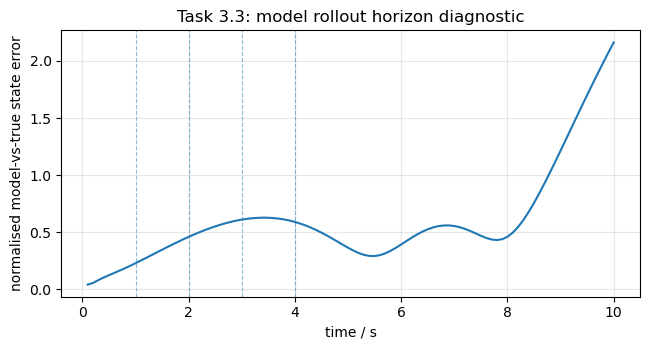

In [12]:
def rollout_arrays_true(p, init_state, horizon, sigmas):
    p_j = jnp.asarray(p, dtype=jnp.float64)
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def body(state, _):
        action = policy_action(p_j, state)
        next_state = cartpole_step_jax(state, action)
        loss_t = point_loss(next_state, sig_j)
        return next_state, (next_state, action, loss_t)

    _, (states, actions, losses) = jax.lax.scan(body, init_j, None, length=horizon)
    states = np.array(states, copy=True)
    states[:, 2] = wrap_angle_np(states[:, 2])
    return states, np.asarray(actions), np.asarray(losses)


def rollout_arrays_model(p, init_state, horizon, sigmas, params):
    p_j = jnp.asarray(p, dtype=jnp.float64)
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def body(state, _):
        action = policy_action(p_j, state)
        next_state = model_step_jax(state, action, params)
        loss_t = point_loss(next_state, sig_j)
        return next_state, (next_state, action, loss_t)

    _, (states, actions, losses) = jax.lax.scan(body, init_j, None, length=horizon)
    states = np.array(states, copy=True)
    states[:, 2] = wrap_angle_np(states[:, 2])
    return states, np.asarray(actions), np.asarray(losses)


def state_error_norm(model_states, true_states):
    diff = np.array(model_states - true_states, copy=True)
    diff[:, 2] = wrap_angle_np(model_states[:, 2] - true_states[:, 2])
    scale = np.array([2.0, 4.0, 1.0, 6.0])
    return np.linalg.norm(diff / scale, axis=1)


near_init = np.array([0.0, 0.0, 0.20, 0.0])
near_sigmas = np.array([1.0, 2.0, 0.45, 3.0])
probe_policy = np.array([0.0, 0.0, 15.0, 3.0])
probe_horizon = max(HORIZON_MODEL_CANDIDATES + [HORIZON_EVAL])

true_probe, _, _ = rollout_arrays_true(probe_policy, near_init, probe_horizon, near_sigmas)
model_probe, _, _ = rollout_arrays_model(probe_policy, near_init, probe_horizon, near_sigmas, model_params)
err_probe = state_error_norm(model_probe, true_probe)

t = np.arange(1, probe_horizon + 1) * DELTA_TIME
fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(t, err_probe)
for h in HORIZON_MODEL_CANDIDATES:
    ax.axvline(h * DELTA_TIME, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("time / s")
ax.set_ylabel("normalised model-vs-true state error")
ax.set_title("Task 3.3: model rollout horizon diagnostic")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "task33_model_rollout_horizon_diagnostic.png", dpi=180)
plt.show()

horizon_diag = pd.DataFrame({"step": np.arange(1, probe_horizon + 1), "time": t, "state_error_norm": err_probe})
horizon_diag.to_csv(LOG_DIR / "task33_model_horizon_diagnostic.csv", index=False)


In [14]:
def make_true_objective(init_state, horizon, sigmas):
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def loss_fn(p):
        return true_rollout_loss(p, init_j, horizon, sig_j)

    val_grad = jax.jit(jax.value_and_grad(loss_fn))

    def objective(p_np):
        val, grad = val_grad(jnp.asarray(p_np, dtype=jnp.float64))
        return float(val), np.asarray(grad, dtype=float)

    return objective


def make_model_objective(init_state, horizon, sigmas, params):
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def loss_fn(p):
        return model_rollout_loss(p, init_j, horizon, sig_j, params)

    val_grad = jax.jit(jax.value_and_grad(loss_fn))

    def objective(p_np):
        val, grad = val_grad(jnp.asarray(p_np, dtype=jnp.float64))
        return float(val), np.asarray(grad, dtype=float)

    return objective


def optimise_policy_from_objective(objective, seed=0, random_restarts=3, maxiter=80, bound=60.0):
    local_rng = np.random.default_rng(seed)
    guesses = [
        np.zeros(4),
        np.array([0.0, 0.0, 12.0, 2.0]),
        np.array([0.0, 0.0, 28.0, 5.0]),
        np.array([2.0, 2.0, 28.0, 5.0]),
        np.array([-2.0, -2.0, 28.0, 5.0]),
        np.array([0.0, 0.0, -12.0, -2.0]),
    ]
    for _ in range(random_restarts):
        guesses.append(local_rng.normal(0.0, 10.0, size=4))

    rows = []
    best = None
    for i, guess in enumerate(guesses):
        result = minimize(
            fun=lambda p: objective(p),
            x0=guess,
            jac=True,
            method="L-BFGS-B",
            bounds=[(-bound, bound)] * 4,
            options={"maxiter": maxiter, "ftol": 1e-9},
        )
        rows.append({
            "restart": i,
            "loss": float(result.fun),
            "success": bool(result.success),
            "p_x": result.x[0],
            "p_x_dot": result.x[1],
            "p_theta": result.x[2],
            "p_theta_dot": result.x[3],
            "message": result.message,
        })
        if best is None or result.fun < best.fun:
            best = result

    return best, pd.DataFrame(rows).sort_values("loss")


def eval_losses_for_policy(p, init_state, model_horizon, eval_horizon, sigmas, params):
    true_obj_short = make_true_objective(init_state, model_horizon, sigmas)
    true_obj_long = make_true_objective(init_state, eval_horizon, sigmas)
    model_obj_short = make_model_objective(init_state, model_horizon, sigmas, params)
    return {
        "model_loss_short": model_obj_short(p)[0],
        "true_loss_short": true_obj_short(p)[0],
        "true_loss_long": true_obj_long(p)[0],
    }


Optimising policy through learned model, horizon=10 steps (1.0 s)
Optimising policy through learned model, horizon=20 steps (2.0 s)
Optimising policy through learned model, horizon=30 steps (3.0 s)
Optimising policy through learned model, horizon=40 steps (4.0 s)


,optimised_on,model_horizon,model_horizon_seconds,optimisation_loss,model_loss_short,true_loss_short,true_loss_long,p_x,p_x_dot,p_theta,p_theta_dot
0,learned_model,10,1.0,0.032351,0.032351,0.081444,0.775747,-21.993706,19.085251,22.477488,9.973189
1,learned_model,20,2.0,0.029420,0.029420,0.070680,0.014455,7.260134,15.873127,30.075887,8.799167
2,learned_model,30,3.0,0.020594,0.020594,0.031371,0.009412,13.454802,9.237083,31.471450,6.383461
3,learned_model,40,4.0,0.016077,0.016077,0.020532,0.008213,12.683797,6.859574,30.938600,5.449587


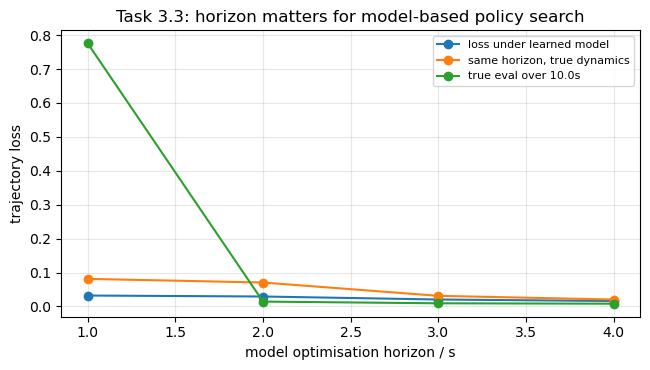

In [16]:
model_policy_rows = []
model_policy_results = {}

for h in HORIZON_MODEL_CANDIDATES:
    print(f"Optimising policy through learned model, horizon={h} steps ({h * DELTA_TIME:.1f} s)")
    obj_model = make_model_objective(near_init, h, near_sigmas, model_params)
    best_model_h, runs_model_h = optimise_policy_from_objective(
        obj_model,
        seed=SEED + 300 + h,
        random_restarts=RANDOM_RESTARTS,
        maxiter=MAXITER,
    )
    p_h = best_model_h.x
    evals = eval_losses_for_policy(p_h, near_init, h, HORIZON_EVAL, near_sigmas, model_params)

    row = {
        "optimised_on": "learned_model",
        "model_horizon": h,
        "model_horizon_seconds": h * DELTA_TIME,
        "optimisation_loss": float(best_model_h.fun),
        **evals,
        "p_x": p_h[0],
        "p_x_dot": p_h[1],
        "p_theta": p_h[2],
        "p_theta_dot": p_h[3],
    }
    model_policy_rows.append(row)
    model_policy_results[h] = {"best": best_model_h, "runs": runs_model_h}

model_policy_df = pd.DataFrame(model_policy_rows)
model_policy_df.to_csv(LOG_DIR / "task33_model_policy_horizon_sweep.csv", index=False)
display(model_policy_df)

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(model_policy_df["model_horizon_seconds"], model_policy_df["model_loss_short"], marker="o", label="loss under learned model")
ax.plot(model_policy_df["model_horizon_seconds"], model_policy_df["true_loss_short"], marker="o", label="same horizon, true dynamics")
ax.plot(model_policy_df["model_horizon_seconds"], model_policy_df["true_loss_long"], marker="o", label=f"true eval over {HORIZON_EVAL * DELTA_TIME:.1f}s")
ax.set_xlabel("model optimisation horizon / s")
ax.set_ylabel("trajectory loss")
ax.set_title("Task 3.3: horizon matters for model-based policy search")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "task33_model_policy_horizon_sweep.png", dpi=180)
plt.show()


In [18]:
# Use the model horizon that gave the best long true evaluation, not necessarily the lowest model loss.
best_h = int(model_policy_df.loc[model_policy_df["true_loss_long"].idxmin(), "model_horizon"])
p_model_best = model_policy_results[best_h]["best"].x
print("Selected model-based horizon:", best_h, "steps")
print("Best model-based policy:", p_model_best)

# True-dynamics policy, using a comparable horizon to the selected model horizon.
true_obj = make_true_objective(near_init, best_h, near_sigmas)
best_true, true_runs = optimise_policy_from_objective(
    true_obj,
    seed=SEED + 500,
    random_restarts=RANDOM_RESTARTS,
    maxiter=MAXITER,
)
p_true = best_true.x
true_runs.to_csv(LOG_DIR / "task33_true_policy_restarts_comparison.csv", index=False)
print("Comparable true-dynamics policy:", p_true)
print("True objective loss:", best_true.fun)

eval_rows = []
for label, p in [("model_optimised", p_model_best), ("true_optimised", p_true)]:
    short_model = make_model_objective(near_init, best_h, near_sigmas, model_params)(p)[0]
    short_true = make_true_objective(near_init, best_h, near_sigmas)(p)[0]
    long_true = make_true_objective(near_init, HORIZON_EVAL, near_sigmas)(p)[0]
    eval_rows.append({
        "policy": label,
        "optimisation_horizon_steps": best_h,
        "model_loss_short": short_model,
        "true_loss_short": short_true,
        "true_loss_long": long_true,
        "p_x": p[0],
        "p_x_dot": p[1],
        "p_theta": p[2],
        "p_theta_dot": p[3],
    })

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(LOG_DIR / "task33_model_vs_true_policy_eval.csv", index=False)
display(eval_df)


Selected model-based horizon: 40 steps
Best model-based policy: [12.68379664  6.8595738  30.93860021  5.44958654]
Comparable true-dynamics policy: [ 4.43568076  4.95639103 31.96600395  5.13169748]
True objective loss: 0.012457067228048103


,policy,optimisation_horizon_steps,model_loss_short,true_loss_short,true_loss_long,p_x,p_x_dot,p_theta,p_theta_dot
0,model_optimised,40,0.016077,0.020532,0.008213,12.683797,6.859574,30.938600,5.449587
1,true_optimised,40,0.038339,0.012457,0.004983,4.435681,4.956391,31.966004,5.131697


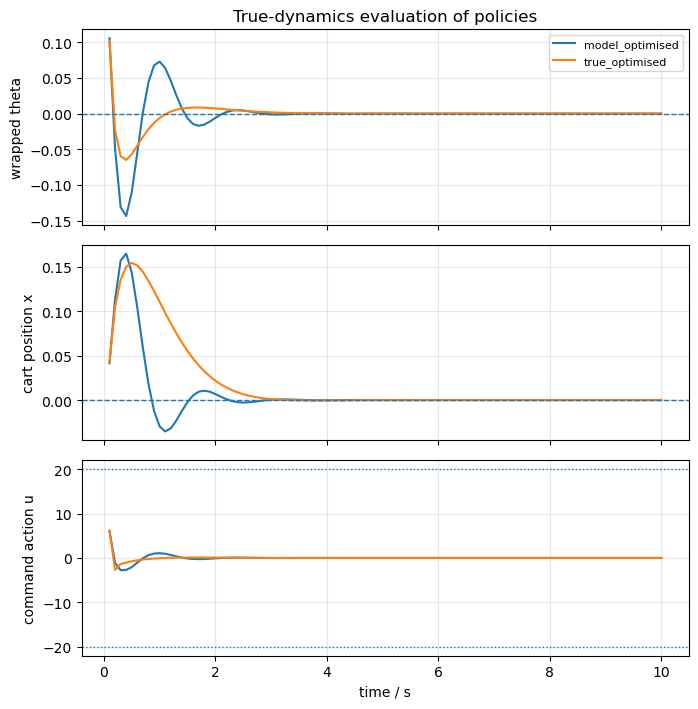

,time,theta_model_optimised,theta_true_optimised,x_model_optimised,x_true_optimised,u_model_optimised,u_true_optimised,loss_model_optimised,loss_true_optimised
0,0.1,0.105701,0.101487,0.041344,0.042736,5.997568,6.183990,0.274189,0.290551
1,0.2,-0.049172,-0.023490,0.113330,0.104590,-1.093766,-2.697499,0.144132,0.046474
2,0.3,-0.131216,-0.059718,0.156835,0.135305,-2.762304,-1.359022,0.070545,0.024883
3,0.4,-0.143611,-0.064938,0.164606,0.150071,-2.683489,-1.064729,0.064714,0.022407
4,0.5,-0.109990,-0.056864,0.143075,0.154127,-2.071926,-0.752991,0.067781,0.020430


In [20]:
def plot_policy_comparison_on_true(p_a, p_b, labels, init_state, horizon, sigmas, filename):
    states_a, actions_a, losses_a = rollout_arrays_true(p_a, init_state, horizon, sigmas)
    states_b, actions_b, losses_b = rollout_arrays_true(p_b, init_state, horizon, sigmas)
    t = np.arange(1, horizon + 1) * DELTA_TIME

    fig, axes = plt.subplots(3, 1, figsize=(7.0, 7.2), sharex=True)

    axes[0].plot(t, states_a[:, 2], label=labels[0])
    axes[0].plot(t, states_b[:, 2], label=labels[1])
    axes[0].axhline(0.0, linestyle="--", linewidth=1)
    axes[0].set_ylabel("wrapped theta")
    axes[0].set_title("True-dynamics evaluation of policies")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].plot(t, states_a[:, 0], label=labels[0])
    axes[1].plot(t, states_b[:, 0], label=labels[1])
    axes[1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1].set_ylabel("cart position x")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, actions_a, label=labels[0])
    axes[2].plot(t, actions_b, label=labels[1])
    axes[2].axhline(ACTION_LIMIT, linestyle=":", linewidth=1)
    axes[2].axhline(-ACTION_LIMIT, linestyle=":", linewidth=1)
    axes[2].set_ylabel("command action u")
    axes[2].set_xlabel("time / s")
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180)
    plt.show()

    df = pd.DataFrame({
        "time": t,
        f"theta_{labels[0]}": states_a[:, 2],
        f"theta_{labels[1]}": states_b[:, 2],
        f"x_{labels[0]}": states_a[:, 0],
        f"x_{labels[1]}": states_b[:, 0],
        f"u_{labels[0]}": actions_a,
        f"u_{labels[1]}": actions_b,
        f"loss_{labels[0]}": losses_a,
        f"loss_{labels[1]}": losses_b,
    })
    return df

comparison_df = plot_policy_comparison_on_true(
    p_model_best,
    p_true,
    labels=("model_optimised", "true_optimised"),
    init_state=near_init,
    horizon=HORIZON_EVAL,
    sigmas=near_sigmas,
    filename="task33_true_eval_model_vs_true_policy.png",
)
comparison_df.to_csv(LOG_DIR / "task33_true_eval_model_vs_true_policy.csv", index=False)
comparison_df.head()


Optimising downward-start policy on learned model for 30 steps only.
Downward model-optimised policy: [-10.86620176  -8.55801579  22.5321714    2.10638226]
Model objective loss: 0.27745107368533056


,case,model_optimisation_horizon,true_eval_horizon,model_objective_loss,true_eval_mean_loss,final_abs_wrapped_theta,max_abs_action,p_x,p_x_dot,p_theta,p_theta_dot
0,downward_model_optimised_policy_true_eval,30,100,0.277451,0.974551,1.736746,19.999975,-10.866202,-8.558016,22.532171,2.106382


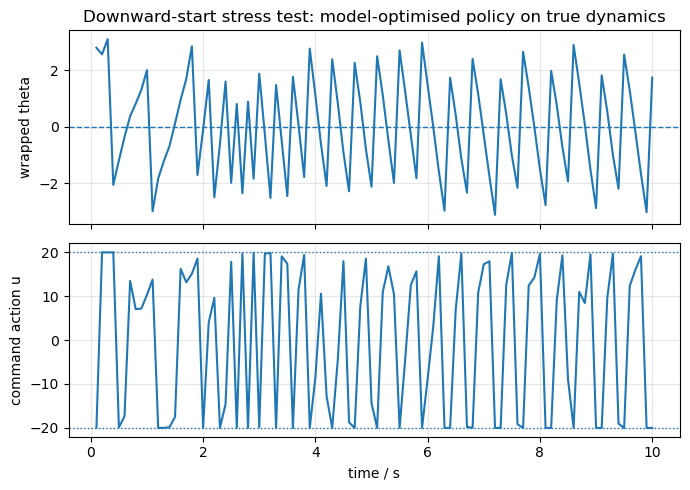

In [22]:
down_init = np.array([0.0, 0.0, np.pi, 0.0])
down_sigmas = np.array([2.0, 4.0, 1.0, 6.0])
H_DOWN_MODEL = min(max(HORIZON_MODEL_CANDIDATES), 30)
H_DOWN_EVAL = max(HORIZON_EVAL, 100)

print(f"Optimising downward-start policy on learned model for {H_DOWN_MODEL} steps only.")
obj_down_model = make_model_objective(down_init, H_DOWN_MODEL, down_sigmas, model_params)
best_down_model, down_model_runs = optimise_policy_from_objective(
    obj_down_model,
    seed=SEED + 700,
    random_restarts=RANDOM_RESTARTS + 1,
    maxiter=MAXITER,
)

down_model_runs.to_csv(LOG_DIR / "task33_downward_model_policy_restarts.csv", index=False)
p_down_model = best_down_model.x
print("Downward model-optimised policy:", p_down_model)
print("Model objective loss:", best_down_model.fun)

states_down_true, actions_down_true, losses_down_true = rollout_arrays_true(
    p_down_model, down_init, H_DOWN_EVAL, down_sigmas
)
t_down = np.arange(1, H_DOWN_EVAL + 1) * DELTA_TIME

down_eval_summary = pd.DataFrame([{
    "case": "downward_model_optimised_policy_true_eval",
    "model_optimisation_horizon": H_DOWN_MODEL,
    "true_eval_horizon": H_DOWN_EVAL,
    "model_objective_loss": float(best_down_model.fun),
    "true_eval_mean_loss": float(np.mean(losses_down_true)),
    "final_abs_wrapped_theta": float(abs(states_down_true[-1, 2])),
    "max_abs_action": float(np.max(np.abs(actions_down_true))),
    "p_x": p_down_model[0],
    "p_x_dot": p_down_model[1],
    "p_theta": p_down_model[2],
    "p_theta_dot": p_down_model[3],
}])
down_eval_summary.to_csv(LOG_DIR / "task33_downward_stress_summary.csv", index=False)
display(down_eval_summary)

fig, axes = plt.subplots(2, 1, figsize=(7.0, 5.0), sharex=True)
axes[0].plot(t_down, states_down_true[:, 2])
axes[0].axhline(0.0, linestyle="--", linewidth=1)
axes[0].set_ylabel("wrapped theta")
axes[0].set_title("Downward-start stress test: model-optimised policy on true dynamics")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_down, actions_down_true)
axes[1].axhline(ACTION_LIMIT, linestyle=":", linewidth=1)
axes[1].axhline(-ACTION_LIMIT, linestyle=":", linewidth=1)
axes[1].set_ylabel("command action u")
axes[1].set_xlabel("time / s")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "task33_downward_model_policy_true_eval.png", dpi=180)
plt.show()
